# Explore Data

In [59]:
import xarray as xr
import yaml

from pathlib import Path
from matplotlib import pyplot as plt

from temp_humidity_index.settings import load_settings

In [63]:
settings = load_settings()
raw_nc_file = settings.raw_nc_path
wet_bulb_nc_file = settings.wet_bulb_nc_path
thi_nc_file = settings.thi_nc_path

In [64]:
# Load the initial dataset before adding wet bulb temperature. 
ds = xr.open_dataset(raw_nc_file)
ds

<xarray.Dataset> Size: 112MB
Dimensions:            (step: 9, latitude: 721, longitude: 1440)
Coordinates:
  * step               (step) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days ...
    valid_time         (step) datetime64[ns] 72B ...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    time               datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables:
    t2m                (step, latitude, longitude) float32 37MB ...
    d2m                (step, latitude, longitude) float32 37MB ...
    msl                (step, latitude, longitude) float32 37MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-02T10:35 GRIB to CDM+CF via cfgrib-0.9.1...

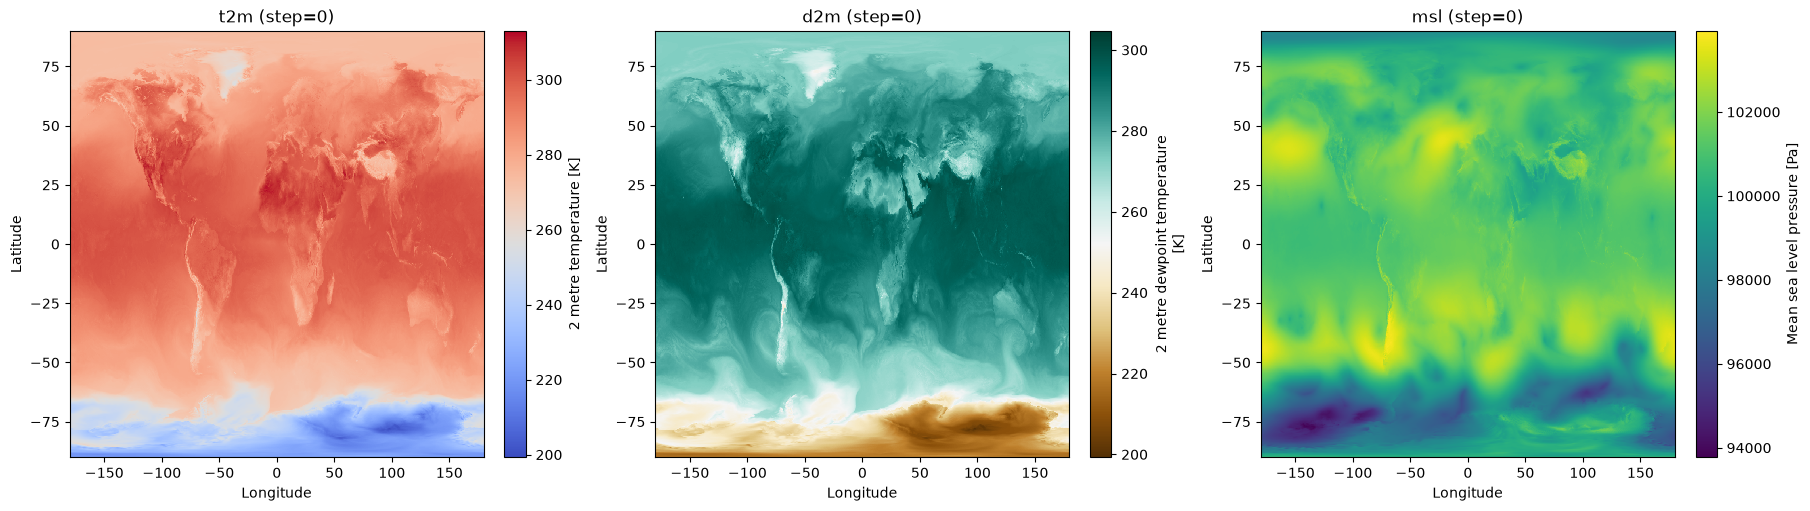

In [65]:
# Plot t2m, d2m and sp for the first available time/step indices
indexers = {}
if "time" in ds.dims:
    indexers["time"] = 0
if "step" in ds.dims:
    indexers["step"] = 0

first_slice = ds.isel(**indexers)

label_parts = [f"{k}=0" for k in ("time", "step") if k in indexers]
label = ", ".join(label_parts) if label_parts else "first slice"

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

first_slice["t2m"].plot(ax=axes[0], cmap="coolwarm")
axes[0].set_title(f"t2m ({label})")

first_slice["d2m"].plot(ax=axes[1], cmap="BrBG")
axes[1].set_title(f"d2m ({label})")

first_slice["msl"].plot(ax=axes[2], cmap="viridis")
axes[2].set_title(f"msl ({label})")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.show()

In [66]:
# Load the dataset with wet bulb temperature added
ds = xr.open_dataset(wet_bulb_nc_file)
ds

<xarray.Dataset> Size: 150MB
Dimensions:            (step: 9, latitude: 721, longitude: 1440)
Coordinates:
  * step               (step) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days ...
    valid_time         (step) datetime64[ns] 72B ...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    time               datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables:
    t2m                (step, latitude, longitude) float32 37MB ...
    d2m                (step, latitude, longitude) float32 37MB ...
    msl                (step, latitude, longitude) float32 37MB ...
    tw                 (step, latitude, longitude) float32 37MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-02T10:35 GRIB to CDM+CF via cfgrib-0.9.1...

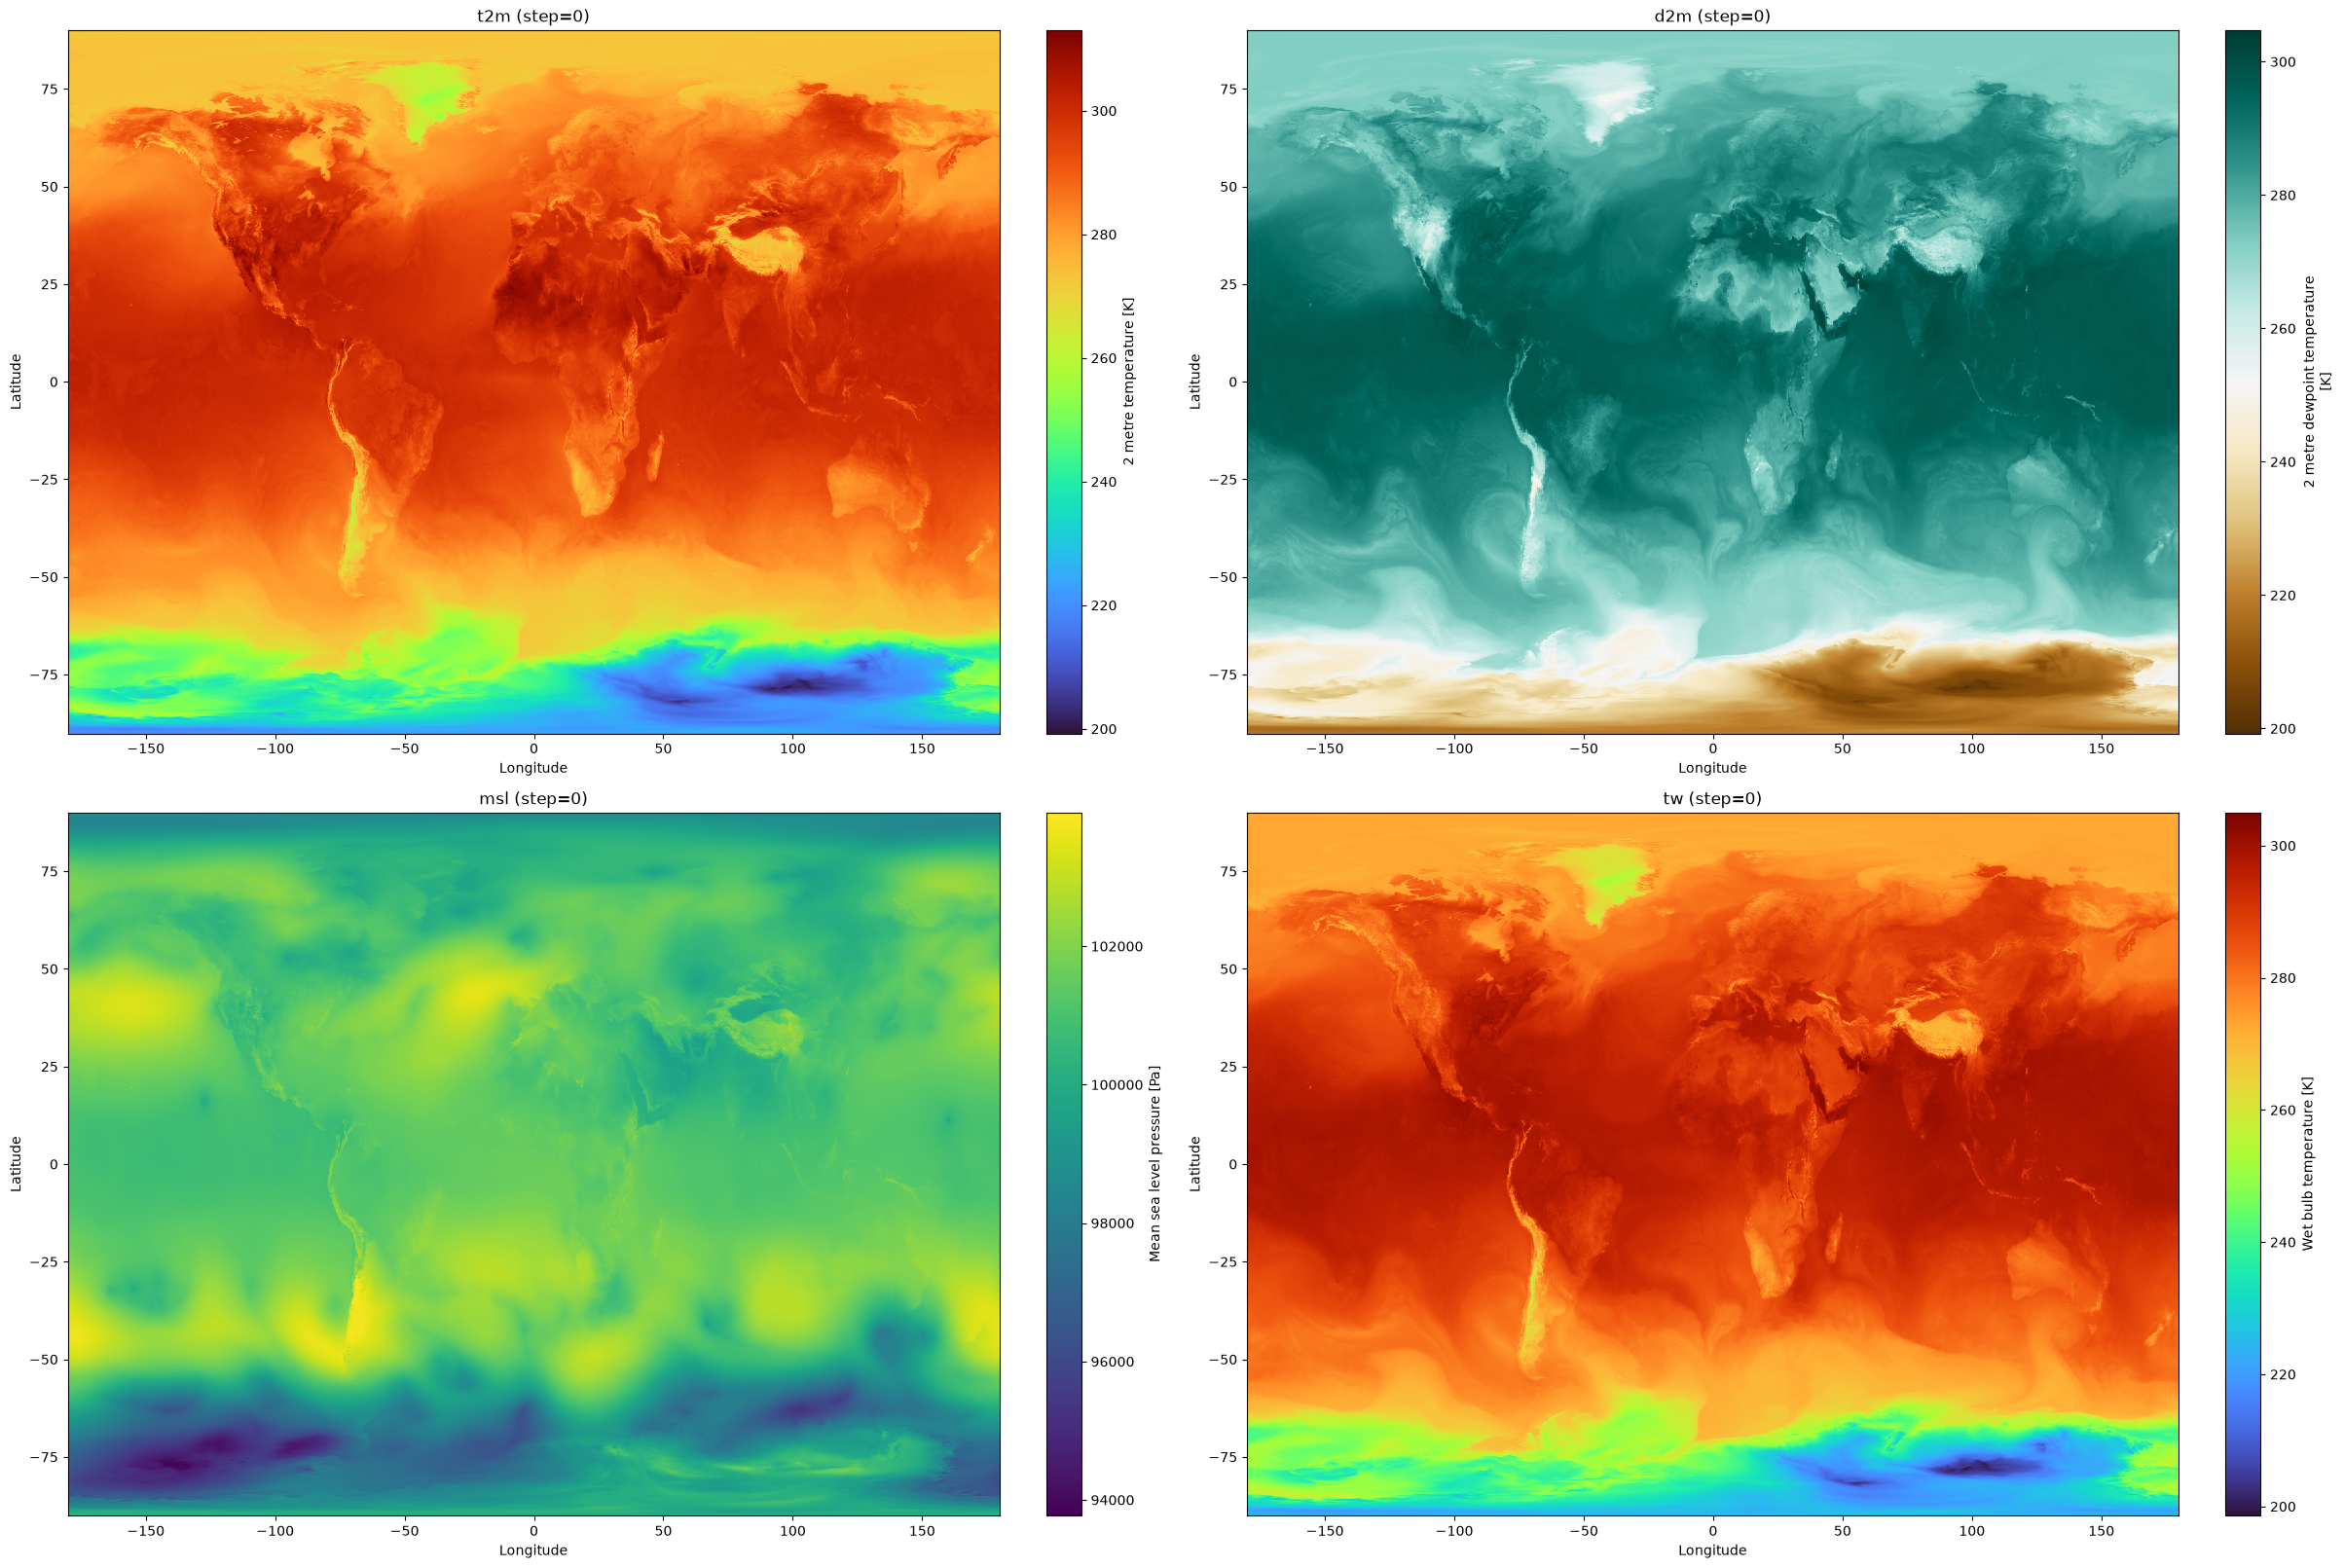

In [67]:
# Plot t2m, d2m, msl, and tw for the first available time/step indices
indexers = {}
if "time" in ds.dims:
    indexers["time"] = 0
if "step" in ds.dims:
    indexers["step"] = 0

first_slice = ds.isel(**indexers)

label_parts = [f"{k}=0" for k in ("time", "step") if k in indexers]
label = ", ".join(label_parts) if label_parts else "first slice"

fig, axes = plt.subplots(2, 2, figsize=(24, 16), constrained_layout=True)
axes = axes.flatten()

first_slice["t2m"].plot(ax=axes[0], cmap="turbo")
axes[0].set_title(f"t2m ({label})")

first_slice["d2m"].plot(ax=axes[1], cmap="BrBG")
axes[1].set_title(f"d2m ({label})")

first_slice["msl"].plot(ax=axes[2], cmap="viridis")
axes[2].set_title(f"msl ({label})")

first_slice["tw"].plot(ax=axes[3], cmap="turbo")
axes[3].set_title(f"tw ({label})")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.show()

Saved: ../charts/ifs_heat_stress_20260701_000.png


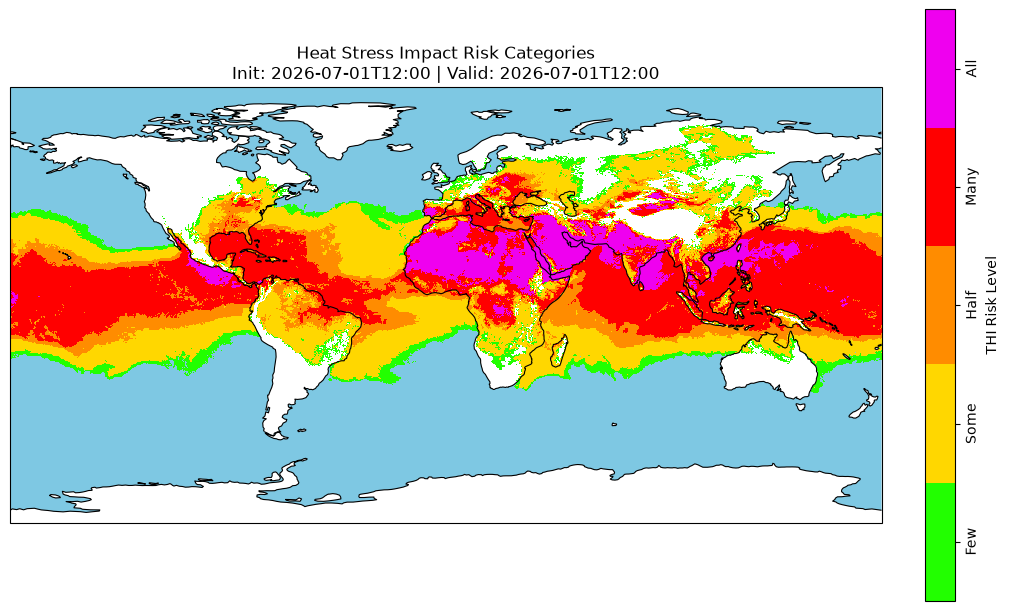

Saved: ../charts/ifs_heat_stress_20260701_006.png


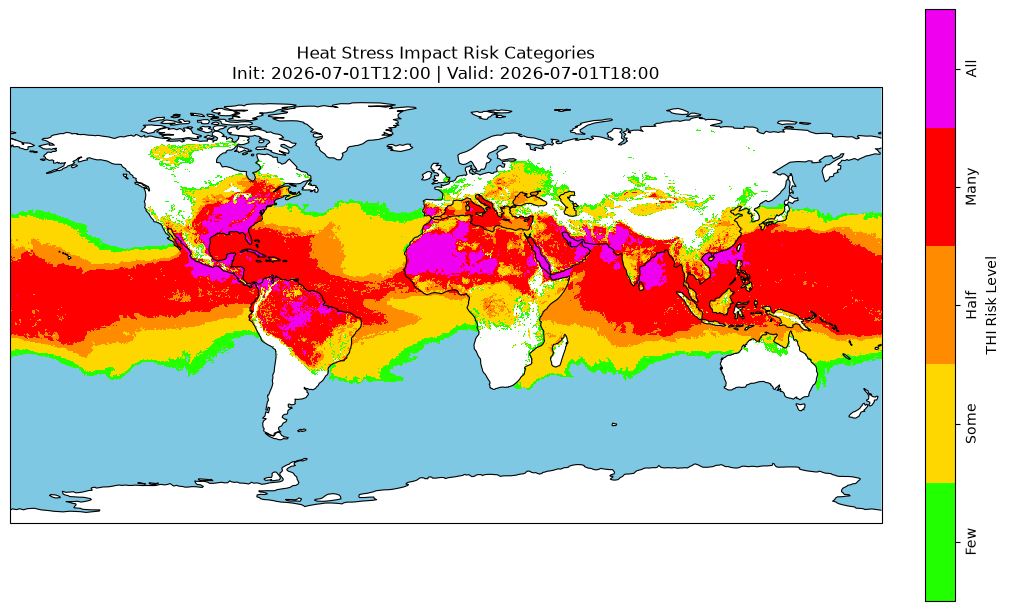

Saved: ../charts/ifs_heat_stress_20260701_012.png


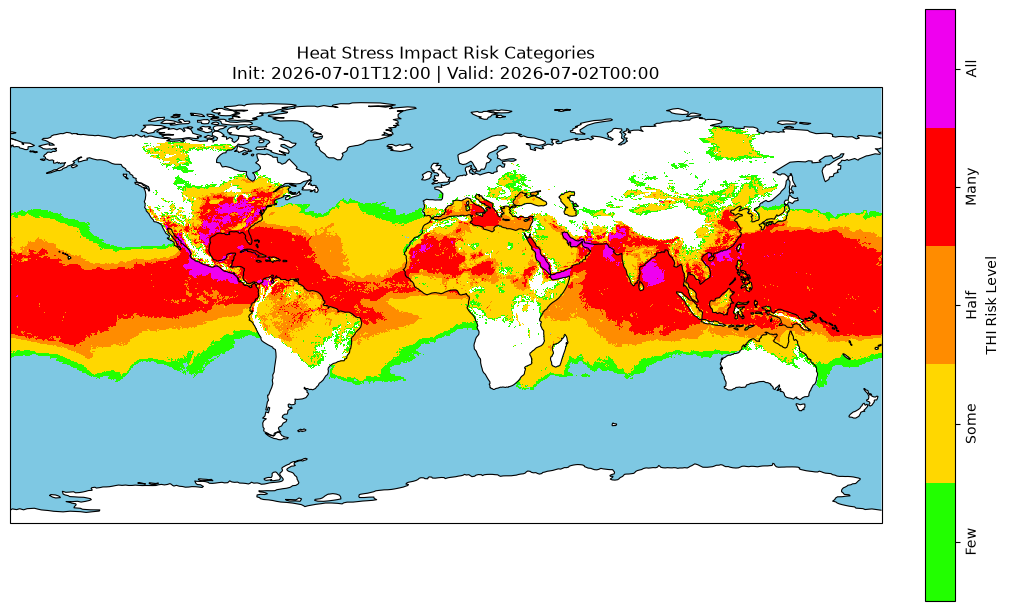

Saved: ../charts/ifs_heat_stress_20260701_018.png


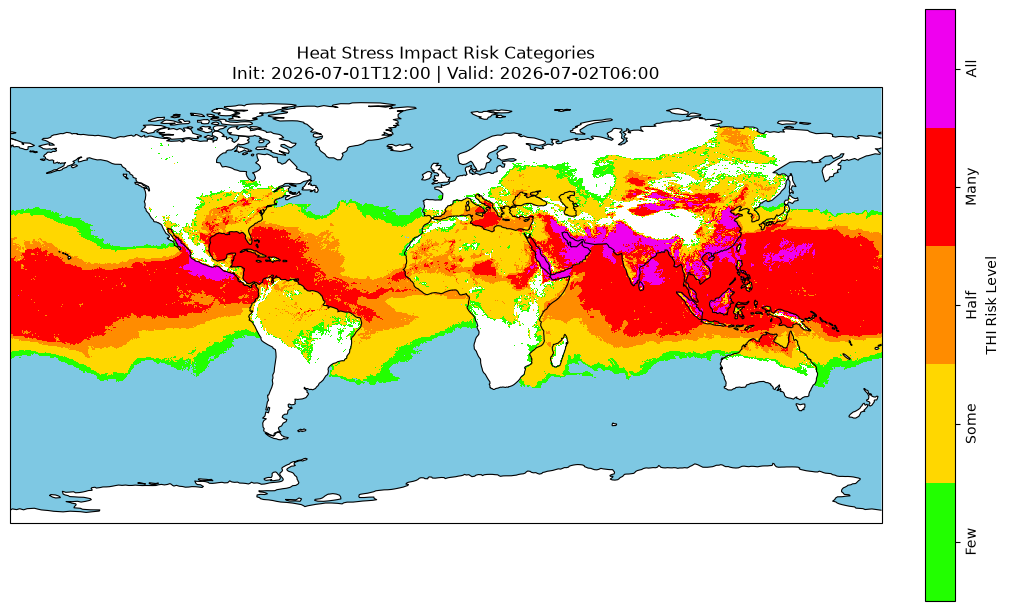

Saved: ../charts/ifs_heat_stress_20260701_024.png


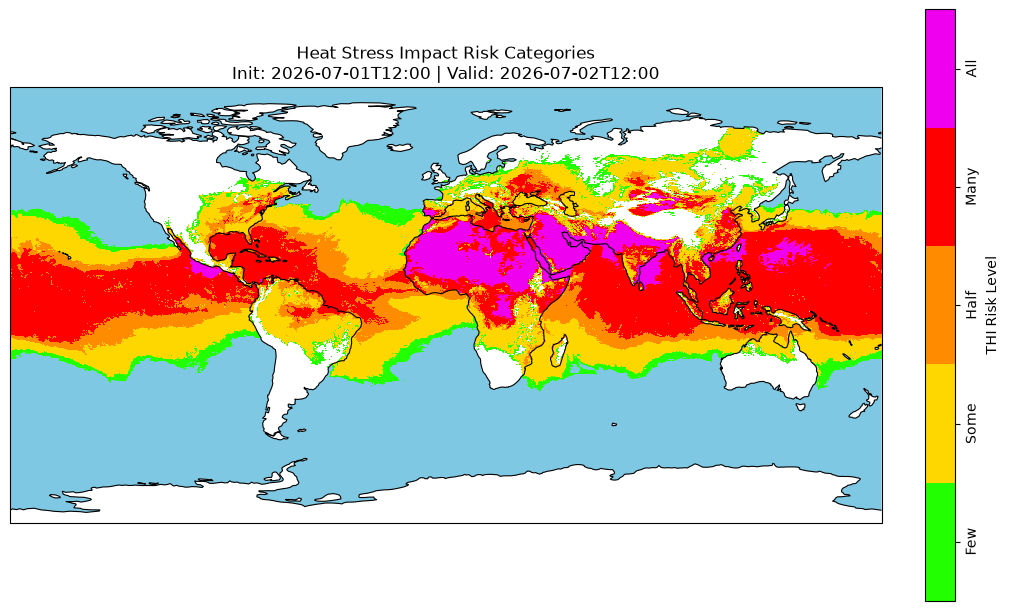

Saved: ../charts/ifs_heat_stress_20260701_030.png


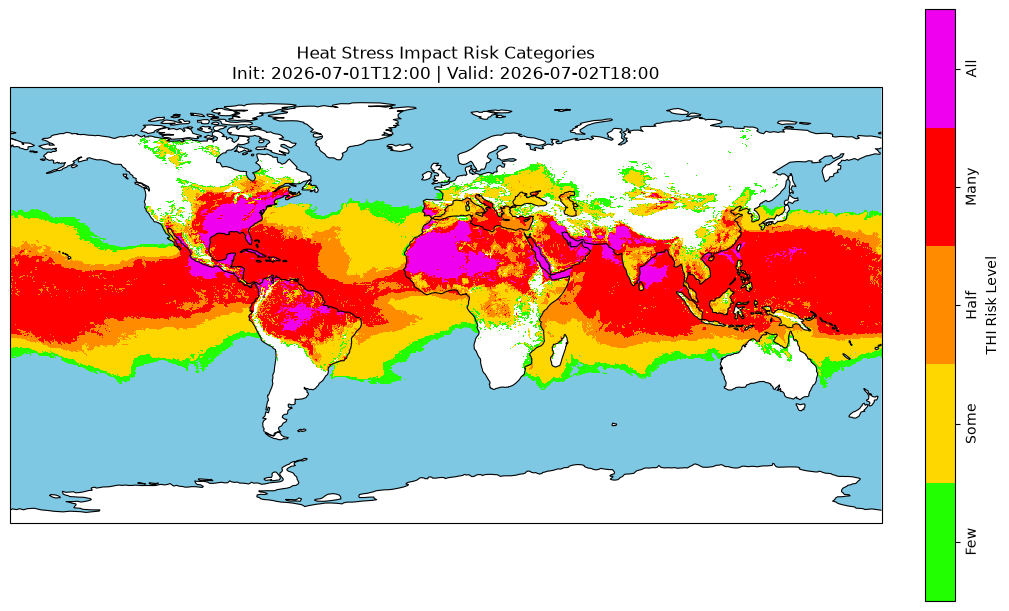

Saved: ../charts/ifs_heat_stress_20260701_036.png


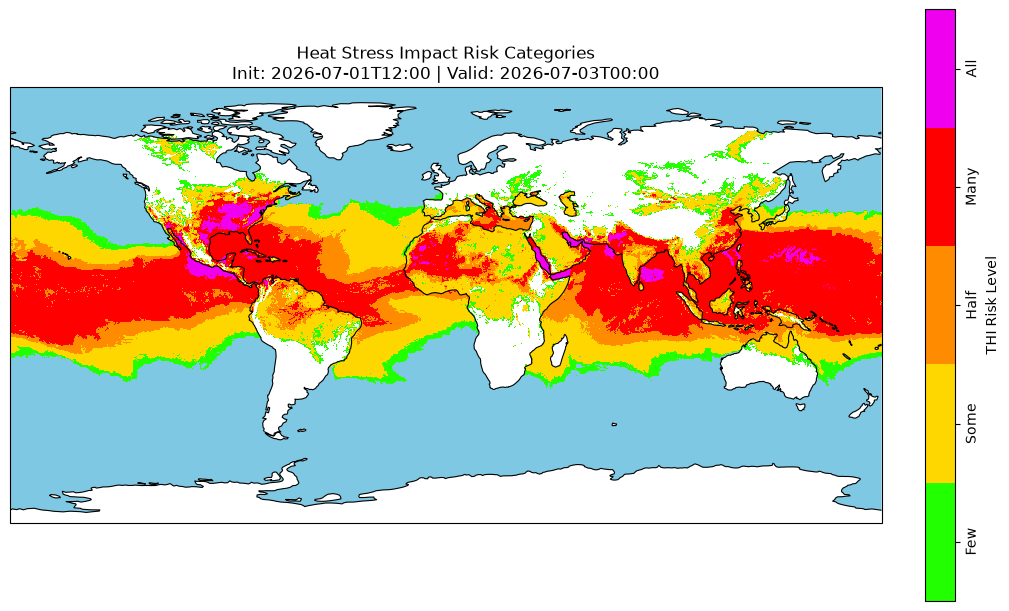

Saved: ../charts/ifs_heat_stress_20260701_042.png


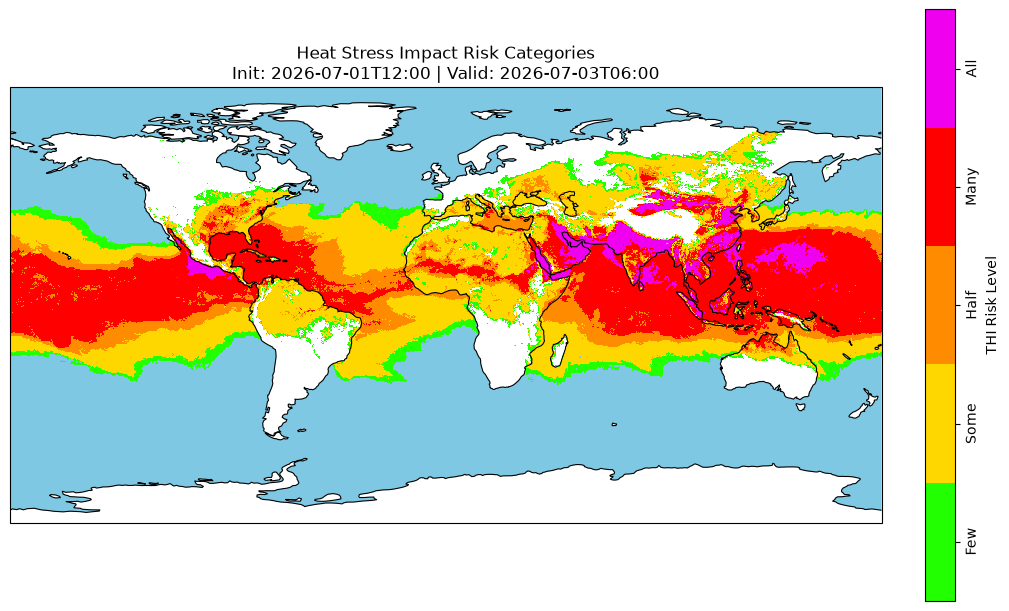

Saved: ../charts/ifs_heat_stress_20260701_048.png


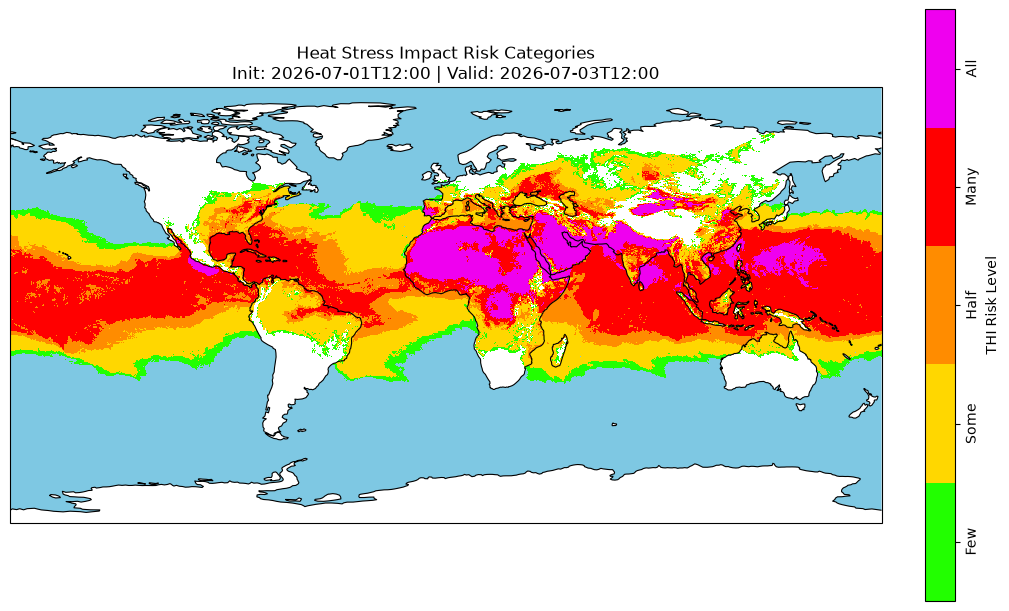

In [ ]:
# Plot THI from [ifs_thi.nc](http://_vscodecontentref_/0) for all available steps, including init and validity times
import numpy as np
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap

ds_thi = xr.open_dataset(thi_nc_file)

# Output directory for images
output_dir = Path(settings.paths.charts_dir)
output_dir.mkdir(parents=True, exist_ok=True)

# THI category thresholds and labels
thresholds = [20, 21, 24, 25, 27]
tick_labels = ["Few", "Some", "Half", "Many", "All"]

# Category colors mapped to indices 0..4
cmap = ListedColormap(["#22FF00", "#FFD700", "#FF8C00", "#FF0000", "#EF00EF"])
# Missing values (including <20) are transparent
cmap.set_bad((1, 1, 1, 0))

# Model initialization time
init_val = None
if "time" in ds_thi.coords:
    time_coord = ds_thi["time"]
    if "time" in time_coord.dims:
        init_val = time_coord.isel(time=0).values
    else:
        init_val = time_coord.values
    init_str = np.datetime_as_string(np.datetime64(init_val), unit="m")
    init_date_str = np.datetime_as_string(np.datetime64(init_val), unit="D").replace("-", "")
else:
    init_str = "N/A"
    init_date_str = "unknown"

# Loop through all steps (or a single slice if no step dimension)
if "step" in ds_thi.dims:
    step_indices = range(ds_thi.sizes["step"])
else:
    step_indices = [None]

for step_idx in step_indices:
    indexers = {}
    if "time" in ds_thi.dims:
        indexers["time"] = 0
    if step_idx is not None:
        indexers["step"] = step_idx

    thi_slice = ds_thi["thi"].isel(**indexers)

    # Determine validity time for this slice
    if "valid_time" in ds_thi.coords:
        vt = ds_thi["valid_time"]
        vt_indexers = {}
        if "time" in vt.dims:
            vt_indexers["time"] = 0
        if "step" in vt.dims and step_idx is not None:
            vt_indexers["step"] = step_idx
        valid_val = vt.isel(**vt_indexers).values if vt_indexers else vt.values
    elif init_val is not None and "step" in ds_thi.coords and step_idx is not None:
        valid_val = np.datetime64(init_val) + ds_thi["step"].isel(step=step_idx).values
    elif init_val is not None:
        valid_val = np.datetime64(init_val)
    else:
        valid_val = None

    valid_str = (
        np.datetime_as_string(np.datetime64(valid_val), unit="m")
        if valid_val is not None
        else "N/A"
    )

    # Step in hours for filename suffix XXX
    if step_idx is not None and "step" in ds_thi.coords:
        step_val = ds_thi["step"].isel(step=step_idx).values
        if np.issubdtype(np.asarray(step_val).dtype, np.timedelta64):
            step_hours = int(step_val / np.timedelta64(1, "h"))
        else:
            step_hours = int(step_val)
    else:
        step_hours = 0
    step_str = f"{step_hours:03d}"

    # Convert THI values to category indices so colorbar labels are centered by construction
    # 0:[20,21), 1:[21,24), 2:[24,25), 3:[25,27), 4:[27,+inf)
    cats = np.digitize(thi_slice.values, bins=thresholds, right=False) - 1
    cats = np.where(np.isfinite(thi_slice.values) & (thi_slice.values >= thresholds[0]), cats, np.nan)
    cat_da = thi_slice.copy(data=cats.astype(float))

    fig, ax = plt.subplots(
        figsize=(10, 6),
        constrained_layout=True,
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    ax.add_feature(cfeature.OCEAN, facecolor="#7EC8E3", edgecolor="none", zorder=0)

    mappable = cat_da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=-0.5,
        vmax=4.5,
        add_colorbar=True,
        cbar_kwargs={"ticks": [0, 1, 2, 3, 4], "label": "THI Risk Level"},
    )

    mappable.colorbar.set_ticklabels(tick_labels)
    for lbl in mappable.colorbar.ax.get_yticklabels():
        lbl.set_rotation(90)
        lbl.set_verticalalignment("center")
        lbl.set_horizontalalignment("left")
    mappable.colorbar.ax.tick_params(pad=4)

    ax.coastlines(linewidth=0.8)
    ax.set_title(
        "Heat Stress Impact Risk Categories\n"
        f"Init: {init_str} | Valid: {valid_str}"
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    out_file = output_dir / f"ifs_heat_stress_{init_date_str}_{step_str}.png"
    fig.savefig(out_file, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_file}")

    plt.show()